<a href="https://colab.research.google.com/github/cokungu1/TT4/blob/main/TUDA_AML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Cognitive AML Screening System: A Hybrid Entity Resolution Approach for Sanctions Screening**



*   Cosmas Ochieng Kungu
*   TUDA Class Project 2026



# 1. Background

Money laundering poses a critical threat to the global financial ecosystem, facilitating crimes ranging from drug trafficking to terrorism financing. In the **Kenyan context**, the risk is amplified by the country's position as a regional financial hub and the rapid adoption of digital finance systems like Mobile Money. According to the **Financial Reporting Centre (FRC)** of Kenya, illicit financial flows often exploit gaps in customer due diligence (CDD) processes (FRC, 2023). To combat this, institutions are mandated by the **Proceeds of Crime and Anti-Money Laundering Act (POCAMLA, 2009)** to screen clients against global sanctions lists (e.g., UN, OFAC). However, traditional exact-match screening systems frequently fail due to the complexity of unstructured text data, such as name variations, transliterations, and culturally specific naming conventions, leading to operational inefficiencies and regulatory risk (FATF, 2024).

**References:**
*   *Financial Reporting Centre (FRC). (2023). Annual Report & Financial Statements 2022/2023. Nairobi: FRC.*
*   *Republic of Kenya. (2009). The Proceeds of Crime and Anti-Money Laundering Act (POCAMLA). Nairobi: National Council for Law Reporting.*
*   *Financial Action Task Force (FATF). (2024). Jurisdictions under Increased Monitoring.*

# 2. Problem Statement and Justification

The primary challenge in Anti-Money Laundering (AML) compliance is the accurate resolution of entities within unstructured textual data. Names in sanctions lists vary significantly from client databases due to misspellings, phonetic variations (e.g., "Mohammed" vs. "Muhammed"), and inconsistent ordering (e.g., "John Kamau" vs. "Kamau, John"). In Kenya, this is further complicated by the anglicization of indigenous names and the lack of standardized spelling for names transliterated from non-Latin scripts (e.g., Arabic or Somali names). Standard rule-based systems often yield high **False Positive rates**, overwhelming compliance officers, or worse, **False Negatives**, allowing sanctioned entities to slip through. There is a critical need for an intelligent Text Analytics solution that utilizes Natural Language Processing (NLP) techniques—specifically approximate string matching and phonetic encoding—to robustly identify high-risk entities despite textual obfuscation.

# 3. Assumptions and Scope

**Assumptions:**
1.  **Data Representativeness:** We assume that the publicly available UN Consolidated List, OFAC SDN List, and OpenSanctions PEP database are up-to-date and representative of the global risk landscape.
2.  **Transliteration:** It is assumed that the primary input data is in the Latin alphabet (English), and any non-Latin characters (e.g., Cyrillic, Arabic) have been transliterated prior to ingestion.
3.  **Name Variations:** We assume that adversarial actors attempt to evade detection primarily through character deletion, substitution, and phonetic obfuscation.

**Scope:**
This project focuses strictly on **Text and Unstructured Data Analytics** applied to **Entity Resolution**. It involves the ingestion of live government XML/CSV data, preprocessing of text fields (normalization), and the development of a hybrid matching engine. The solution is scoped to name screening (string similarity) and does not extend to transaction monitoring (graph network analysis) or behavioral profiling.

# 4. NLP Hypothesis

We hypothesize that a **Hybrid Entity Resolution Engine** integrating **Phonetic Encoding (Metaphone)** and **Edit-Distance Metrics (Levenshtein & Jaro-Winkler)** will significantly outperform standard exact-matching algorithms in detecting sanctioned entities. Specifically, we posit that:
1.  **Levenshtein Distance** will effectively capture typographical errors and character deletions common in manual data entry.
2.  **Metaphone encoding** will reduce False Negatives caused by sound-alike variations often seen in the transliteration of names in the East African region.
3.  **Jaro-Winkler similarity** will account for prefix-weighting, ensuring that variations at the start of names (often crucial in determining identity) are penalized less than trailing errors.
By combining these unstructured text analytics techniques, the system aims to achieve a Recall of >80% on adversarially corrupted test sets while minimizing operational noise.

STEP 0: INSTALLING REQUIRED LIBRARIES

In [1]:
# Install necessary libraries
!pip install pandas numpy requests xmltodict feedparser rapidfuzz transformers \
             torch seaborn matplotlib scikit-learn phonetics jellyfish wordcloud \
             plotly kaleido openpyxl

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 2.5 MB/s eta 0:00:00
  Created wheel for phonetics: filename=phonetics-1.0.5-py2.py3-none-any.whl size=8696 sha256=d228596f9742b6d6920b6d17640af7661c12a49d4aaf5d3fd3341bd30e50dac2
  Stored in directory: /root/.cache/pip/wheels/4e/d0/ca/0abf0e0c628782f163861d5daf61c192f61b611aa235c40f52
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=c0c03048cdbe0731f7c1c69ac0c337c12557fb9a5a97d1d2f942f9f82d0fe2c2
  Stored in directory: /root/.cache/pip/wheels/03/f5/1a/23761066dac1d0e8e683e5fdb27e12de53209d05a4a37e624

"STEP 1: IMPORTING LIBRARIES"

In [2]:

# Data Processing
import pandas as pd
import numpy as np
from collections import Counter
import json
from datetime import datetime
import time
import warnings
warnings.filterwarnings('ignore')

# Web APIs & Data Fetching
import requests
try:
    import xmltodict
except ImportError:
    print("xmltodict not found. Attempting to install...")
    !pip install xmltodict
    import xmltodict # Re-import after installation
try:
    import feedparser
except ImportError:
    print("feedparser not found. Attempting to install...")
    !pip install feedparser
    import feedparser # Re-import after installation
from urllib.parse import quote_plus

# String Matching & NLP
from rapidfuzz import process, fuzz
import phonetics
import jellyfish

# Machine Learning
import sklearn
from transformers import pipeline
from sklearn.metrics import (recall_score, precision_score, confusion_matrix,
                            classification_report, roc_curve, auc)
from sklearn.preprocessing import StandardScaler

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Set visualization styles
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully.")

Libraries imported successfully.


STEP 2: LIVE DATA INGESTION FROM REPUTABLE AGENCY SOURCES

In [4]:
class LiveAMLDataLake:
    def __init__(self):
        self.database = pd.DataFrame()
        self.ingestion_log = []
        self._ingest_live_data()
        self._inject_demo_data()

    def _log_ingestion(self, source, status, count=0, error=None):
        self.ingestion_log.append({
            'timestamp': datetime.now().isoformat(),
            'source': source,
            'status': status,
            'records': count,
            'error': str(error) if error else None
        })

    def _clean_un_name(self, name_parts):
        """Helper to join name parts and remove 'na' strings"""
        # UN data often contains 'na'. We filter those out.
        clean_parts = [str(p) for p in name_parts if p and str(p).lower() != 'na']
        return " ".join(clean_parts).strip()

    def _ingest_live_data(self):
        print(" Connecting to Government Servers...")

        # 1. RECONFIGURED UN CONSOLIDATED LIST
        try:
            print("\n [1/3] Downloading UN Sanctions List (Individuals & Entities)...")
            r = requests.get("https://scsanctions.un.org/resources/xml/en/consolidated.xml", timeout=60)
            data_dict = xmltodict.parse(r.content)
            un_rows = []

            # --- PROCESS INDIVIDUALS ---
            indiv_data = data_dict.get('CONSOLIDATED_LIST', {}).get('INDIVIDUALS', {}).get('INDIVIDUAL', [])
            if not isinstance(indiv_data, list): indiv_data = [indiv_data] # Handle single entry cases

            for ind in indiv_data:
                # Primary Name (Parts 1, 2, 3, 4)
                primary_name = self._clean_un_name([
                    ind.get('FIRST_NAME', ''),
                    ind.get('SECOND_NAME', ''),
                    ind.get('THIRD_NAME', ''),
                    ind.get('FOURTH_NAME', '')
                ])

                if primary_name:
                    un_rows.append({"Name": primary_name, "Type": "Sanction (UN Individual)", "Source": "UN Security Council", "Score": 100})

                # IMPORTANT: Ingest Good Quality Aliases (A.K.A.s)
                # This is what caught your 'AAMIR ALI CHAUDHRY' variations
                aka_list = ind.get('INDIVIDUAL_ALIAS', [])
                if not isinstance(aka_list, list): aka_list = [aka_list]

                for aka in aka_list:
                    if aka.get('QUALITY', '').lower() == 'good':
                        alias_name = aka.get('ALIAS_NAME', '')
                        if alias_name and alias_name.lower() != 'na':
                            un_rows.append({"Name": alias_name, "Type": "Sanction (UN Alias)", "Source": "UN Security Council", "Score": 100})

            # --- PROCESS ENTITIES (Organizations like Al-Shabaab) ---
            entity_data = data_dict.get('CONSOLIDATED_LIST', {}).get('ENTITIES', {}).get('ENTITY', [])
            if not isinstance(entity_data, list): entity_data = [entity_data]

            for ent in entity_data:
                ent_name = ent.get('FIRST_NAME', '')
                if ent_name and ent_name.lower() != 'na':
                    un_rows.append({"Name": ent_name, "Type": "Sanction (UN Entity)", "Source": "UN Security Council", "Score": 100})

            self.database = pd.concat([self.database, pd.DataFrame(un_rows)], ignore_index=True)
            print(f" UN: {len(un_rows):,} names/aliases/entities loaded.")
            self._log_ingestion("UN", "Success", len(un_rows))

        except Exception as e:
            print(f" UN Load Error: {e}")
            self._log_ingestion("UN", "Failed", error=e)

        # 2. OFAC SDN LIST
        try:
            print("\n [2/3] Downloading OFAC SDN List...")
            url = "https://www.treasury.gov/ofac/downloads/sdn.csv"
            # OFAC CSV: Col 1 is ID, Col 2 is Name, Col 3 is Type
            ofac_df = pd.read_csv(url, header=None, encoding='latin-1', usecols=[1, 2], names=['Name', 'RawType'])
            ofac_df['Name'] = ofac_df['Name'].astype(str).str.replace('-0-', '').str.strip()
            ofac_df['Type'] = "Sanction (OFAC)"
            ofac_df['Source'] = "US Treasury"
            ofac_df['Score'] = 100
            self.database = pd.concat([self.database, ofac_df[['Name', 'Type', 'Source', 'Score']]], ignore_index=True)
            print(f" OFAC: {len(ofac_df):,} entities loaded.")
        except Exception as e:
            print(f" OFAC Load Error: {e}")

        # 3. PEP LIST (Optimized for speed)
        try:
            print("\n [3/3] Downloading OpenSanctions PEP List...")
            pep_url = "https://data.opensanctions.org/datasets/latest/peps/targets.simple.csv"
            pep_df = pd.read_csv(pep_url, on_bad_lines='skip', nrows=50000) # Faster load
            pep_df = pep_df.rename(columns={'caption': 'Name', 'schema': 'Type'})
            pep_df['Source'] = "OpenSanctions PEP DB"
            pep_df['Score'] = 50
            self.database = pd.concat([self.database, pep_df[['Name', 'Type', 'Source', 'Score']]], ignore_index=True)
            print(f" PEP: {len(pep_df):,} entities loaded.")
        except Exception as e:
            print(f" PEP Load Error: {e}")

    def _inject_demo_data(self):
        # Keep your VIPs to ensure the demo always hits
        demo_data = [
            {"Name": "Osama Bin Laden", "Type": "Sanction (UN)", "Source": "UN Security Council", "Score": 100},
            {"Name": "Dahabshiil Transfer Services", "Type": "Organization", "Source": "Watchlist", "Score": 75}
        ]
        self.database = pd.concat([self.database, pd.DataFrame(demo_data)], ignore_index=True)
        self.database.drop_duplicates(subset=['Name'], inplace=True)
        print(f" DATA LAKE HYDRATED: {len(self.database):,} Total Unique Entities")

    def get_database(self):
        return self.database

In [7]:
import pandas as pd
import requests
import xmltodict
import time
from datetime import datetime

class LiveAMLDataLake:
    def __init__(self):
        self.database = pd.DataFrame()
        self.ingestion_log = []
        self._ingest_live_data()
        self._inject_demo_data()

    def _clean_un_name(self, name_parts):
        """Standardizes UN names and prevents NoneType errors."""
        # The 'or ""' ensures that if a part is None, it becomes an empty string
        clean_parts = [str(p or "").strip() for p in name_parts if p and str(p).lower() != 'na']
        return " ".join(clean_parts).strip()

    def _ingest_live_data(self):
        print("🚀 Connecting to Global Sanction Servers...")

        # 1. FIXED UN CONSOLIDATED LIST
        try:
            print(" [1/3] Downloading UN Sanctions List...")
            r = requests.get("https://scsanctions.un.org/resources/xml/en/consolidated.xml", timeout=60)
            data_dict = xmltodict.parse(r.content)
            un_rows = []

            # Navigate to Individuals
            indiv_section = data_dict.get('CONSOLIDATED_LIST', {}).get('INDIVIDUALS', {})
            if indiv_section:
                indiv_data = indiv_section.get('INDIVIDUAL', [])
                if not isinstance(indiv_data, list): indiv_data = [indiv_data]

                for ind in indiv_data:
                    # Fix: use 'or ""' to prevent NoneType attribute errors
                    p_name = self._clean_un_name([
                        ind.get('FIRST_NAME'), ind.get('SECOND_NAME'),
                        ind.get('THIRD_NAME'), ind.get('FOURTH_NAME')
                    ])
                    if p_name:
                        un_rows.append({"Name": p_name, "Type": "Sanction (UN)", "Source": "UN Security Council", "Score": 100})

                    # Fix: Safety check for Aliases
                    aka_list = ind.get('INDIVIDUAL_ALIAS', [])
                    if aka_list:
                        if not isinstance(aka_list, list): aka_list = [aka_list]
                        for aka in aka_list:
                            quality = str(aka.get('QUALITY') or "").lower()
                            if quality == 'good':
                                alias = aka.get('ALIAS_NAME')
                                if alias and str(alias).lower() != 'na':
                                    un_rows.append({"Name": str(alias), "Type": "Sanction (UN Alias)", "Source": "UN Security Council", "Score": 100})

            # Navigate to Entities
            entity_section = data_dict.get('CONSOLIDATED_LIST', {}).get('ENTITIES', {})
            if entity_section:
                ent_data = entity_section.get('ENTITY', [])
                if not isinstance(ent_data, list): ent_data = [ent_data]
                for ent in ent_data:
                    e_name = ent.get('FIRST_NAME')
                    if e_name and str(e_name).lower() != 'na':
                        un_rows.append({"Name": str(e_name), "Type": "Sanction (UN Entity)", "Source": "UN Security Council", "Score": 100})

            if un_rows:
                self.database = pd.concat([self.database, pd.DataFrame(un_rows)], ignore_index=True)
                print(f" ✅ UN: {len(un_rows):,} names/aliases loaded.")
        except Exception as e:
            print(f" ❌ UN Load Error: {e}")

        # 2. OFAC SDN LIST
        try:
            print(" [2/3] Downloading OFAC SDN List...")
            url = "https://www.treasury.gov/ofac/downloads/sdn.csv"
            ofac_df = pd.read_csv(url, header=None, encoding='latin-1', usecols=[1, 2], names=['Name', 'RawType'])
            ofac_df['Name'] = ofac_df['Name'].astype(str).str.replace('-0-', '').str.strip()
            ofac_df['Type'] = "Sanction (OFAC)"
            ofac_df['Source'] = "US Treasury"
            ofac_df['Score'] = 100
            self.database = pd.concat([self.database, ofac_df[['Name', 'Type', 'Source', 'Score']]], ignore_index=True)
            print(f" ✅ OFAC: {len(ofac_df):,} entities loaded.")
        except Exception as e:
            print(f" ❌ OFAC Load Error: {e}")

        # 3. FIXED PEP LIST (Robust Column Detection)
        try:
            print(" [3/3] Downloading OpenSanctions PEP List...")
            pep_url = "https://data.opensanctions.org/datasets/latest/peps/targets.simple.csv"
            pep_df = pd.read_csv(pep_url, on_bad_lines='skip', nrows=20000)

            # Debug: Check headers and rename dynamically
            if 'caption' in pep_df.columns:
                pep_df = pep_df.rename(columns={'caption': 'Name'})
            elif 'name' in pep_df.columns:
                pep_df = pep_df.rename(columns={'name': 'Name'})

            if 'schema' in pep_df.columns:
                pep_df = pep_df.rename(columns={'schema': 'Type'})

            # Only select columns if they were successfully renamed/found
            if 'Name' in pep_df.columns:
                pep_df['Source'] = "OpenSanctions PEP DB"
                pep_df['Score'] = 50
                # Ensure we only keep columns we need to avoid 'not in index' errors
                pep_to_concat = pep_df[['Name', 'Type', 'Source', 'Score']]
                self.database = pd.concat([self.database, pep_to_concat], ignore_index=True)
                print(f" ✅ PEP: {len(pep_to_concat):,} entities loaded.")
            else:
                print(" ❌ PEP Error: Could not find Name column in CSV.")
        except Exception as e:
            print(f" ❌ PEP Load Error: {e}")

    def _inject_demo_data(self):
        demo_data = [
            {"Name": "Dahabshiil Transfer Services", "Type": "Organization", "Source": "Watchlist", "Score": 75},
            {"Name": "Osama Bin Laden", "Type": "Sanction (UN)", "Source": "UN Security Council", "Score": 100}
        ]
        self.database = pd.concat([self.database, pd.DataFrame(demo_data)], ignore_index=True)
        self.database.drop_duplicates(subset=['Name'], inplace=True)
        print(f"\n💎 DATA LAKE READY: {len(self.database):,} Total Unique Records.")

    def get_database(self):
        return self.database

# Initialize
data_lake = LiveAMLDataLake()
db = data_lake.get_database()

🚀 Connecting to Global Sanction Servers...
 [1/3] Downloading UN Sanctions List...
 ✅ UN: 2,551 names/aliases loaded.
 [2/3] Downloading OFAC SDN List...
 ✅ OFAC: 18,699 entities loaded.
 [3/3] Downloading OpenSanctions PEP List...
 ✅ PEP: 20,000 entities loaded.

💎 DATA LAKE READY: 40,992 Total Unique Records.


In [5]:
# Initialize
data_lake = LiveAMLDataLake()

 Connecting to Government Servers...

 [1/3] Downloading UN Sanctions List (Individuals & Entities)...
 UN Load Error: 'NoneType' object has no attribute 'lower'

 [2/3] Downloading OFAC SDN List...
 OFAC: 18,699 entities loaded.

 [3/3] Downloading OpenSanctions PEP List...
 PEP Load Error: "['Name'] not in index"
 DATA LAKE HYDRATED: 18,667 Total Unique Entities


In [ ]:
# =============================================================================
# STEP 2: LIVE DATA INGESTION (WITH VIP INJECTION FOR DEMO)
# =============================================================================
class LiveAMLDataLake:
    def __init__(self):
        self.database = pd.DataFrame()
        self.metadata = {}
        self.ingestion_log = []
        self._ingest_live_data()
        self._inject_demo_data() # <--- NEW: Forces VIPs into the system

    def _log_ingestion(self, source, status, count=0, error=None):
        self.ingestion_log.append({
            'timestamp': datetime.now().isoformat(),
            'source': source,
            'status': status,
            'records': count,
            'error': str(error) if error else None
        })

    def _ingest_live_data(self):
        print(" Connecting to Government Servers...")
        start_time = time.time()

        # 1. UN CONSOLIDATED LIST
        try:
            print("\n [1/3] Downloading UN Sanctions List...")
            r = requests.get("https://scsanctions.un.org/resources/xml/en/consolidated.xml", timeout=60)
            data_dict = xmltodict.parse(r.content)
            un_rows = []
            individuals = data_dict.get('CONSOLIDATED_LIST', {}).get('INDIVIDUALS', {}).get('INDIVIDUAL', [])
            for ind in individuals:
                fname = ind.get('FIRST_NAME', '')
                sname = ind.get('SECOND_NAME', '')
                tname = ind.get('THIRD_NAME', '')
                # normalize to string
                full_name = f"{fname} {sname} {tname}".strip()
                if full_name:
                    un_rows.append({"Name": full_name, "Type": "Sanction (UN)", "Source": "UN Security Council", "Score": 100})

            self.database = pd.concat([self.database, pd.DataFrame(un_rows)], ignore_index=True)
            print(f" UN: {len(un_rows):,} entities loaded.")
        except Exception as e:
            print(f" UN Load Error: {e}")

        # 2. OFAC SDN LIST
        try:
            print("\n [2/3] Downloading OFAC SDN List...")
            url = "https://www.treasury.gov/ofac/downloads/sdn.csv"
            ofac_df = pd.read_csv(url, header=None, encoding='latin-1', usecols=[1, 2], names=['Name', 'EntityType'])
            ofac_df['Name'] = ofac_df['Name'].astype(str).str.replace('-0-', '').str.strip()
            ofac_df['Type'] = "Sanction (OFAC)"
            ofac_df['Source'] = "US Treasury"
            ofac_df['Score'] = 100

            self.database = pd.concat([self.database, ofac_df[['Name', 'Type', 'Source', 'Score']]], ignore_index=True)
            print(f" OFAC: {len(ofac_df):,} entities loaded.")
        except Exception as e:
            print(f" OFAC Load Error: {e}")

        # 3. PEP LIST (INCREASED SAMPLE SIZE & ROBUSTNESS)
        try:
            print("\n [3/3] Downloading Global PEP List (OpenSanctions)...")
            pep_url = "https://data.opensanctions.org/datasets/latest/peps/targets.simple.csv"
            pep_df = pd.read_csv(pep_url, on_bad_lines='skip')

            # Normalize columns
            cols = pep_df.columns.tolist()
            name_col = 'caption' if 'caption' in cols else 'name'
            type_col = 'schema' if 'schema' in cols else 'type'

            if name_col in cols:
                pep_df = pep_df[[name_col, type_col]].rename(columns={name_col: 'Name', type_col: 'Type'})
                pep_df['Source'] = "OpenSanctions PEP DB"
                pep_df['Score'] = 50

                # INCREASE SAMPLE SIZE TO 50,000 to catch more names
                self.database = pd.concat([self.database, pep_df.head(50000)], ignore_index=True)
                print(f" PEP: 50,000 entities loaded (Sampled).")
        except Exception as e:
            print(f" PEP Load Error: {e}")

    def _inject_demo_data(self):
        """Manually injects specific names to ensure the demo works for the presentation"""
        print("\n [4/4] Injecting Known High-Risk Entities for Demo...")
        demo_data = [
            {"Name": "Osama Bin Laden", "Type": "Sanction (UN)", "Source": "UN Security Council", "Score": 100},
            {"Name": "Uhuru Muigai Kenyatta", "Type": "Person", "Source": "OpenSanctions PEP DB", "Score": 50},
            {"Name": "Donald John Trump", "Type": "Person", "Source": "OpenSanctions PEP DB", "Score": 50},
            {"Name": "Al-Shabaab", "Type": "Organization", "Source": "UN Security Council", "Score": 100},
            {"Name": "Dahabshiil Transfer Services", "Type": "Organization", "Source": "Watchlist", "Score": 75},
            {"Name": "ISIL (Da'esh)", "Type": "Organization", "Source": "UN Security Council", "Score": 100},
            {"Name": "Felicien Kabuga", "Type": "Sanction (UN)", "Source": "UN Security Council", "Score": 100}
        ]
        self.database = pd.concat([self.database, pd.DataFrame(demo_data)], ignore_index=True)
        # Final Cleanup
        self.database = self.database.drop_duplicates(subset=['Name'])
        print(f" DATA LAKE HYDRATED: {len(self.database):,} Total Unique Entities (Inc. VIPs)")

    def get_database(self):
        return self.database

# Initialize
data_lake = LiveAMLDataLake()

 Connecting to Government Servers...

 [1/3] Downloading UN Sanctions List...
 UN: 733 entities loaded.

 [2/3] Downloading OFAC SDN List...
 OFAC: 18,699 entities loaded.

 [3/3] Downloading Global PEP List (OpenSanctions)...
 PEP: 50,000 entities loaded (Sampled).

 [4/4] Injecting Known High-Risk Entities for Demo...
 DATA LAKE HYDRATED: 69,170 Total Unique Entities (Inc. VIPs)


# 5. Data Description

The project utilizes a corpus of unstructured text data derived from three authoritative sources:
1.  **UN Consolidated Sanctions List (XML):** Contains ~700+ entities subject to UN Security Council measures. Key text features include `FIRST_NAME`, `SECOND_NAME`, and `THIRD_NAME`.
2.  **OFAC SDN List (CSV):** The US Treasury’s Specially Designated Nationals list, contributing ~18,000 entities. This dataset includes complex corporate names and vessel names.
3.  **OpenSanctions PEP Database (CSV):** A sampled subset (~20,000 records) of Politically Exposed Persons.

**NLP Features:**
To facilitate text analysis, the following features are extracted and normalized:
*   **Normalized Name:** converted to lowercase, stripped of special characters (noise removal), and standardized to ASCII.
*   **Name Length:** Character count used to filter statistical outliers (e.g., extremely short names that cause high False Positives).
*   **Word Count:** Token count to distinguish between individuals (typically 2-4 tokens) and organizations (often >4 tokens).

STEP 3: EXPLORATORY DATA ANALYSIS (EDA)

In [ ]:

db = data_lake.get_database()
# metadata = data_lake.get_metadata()

# 3.1 Basic Statistics
print("\n Dataset Overview:")
print(f"   Total Records: {len(db):,}")
print(f"   Total Columns: {len(db.columns)}")
print(f"   Memory Usage: {db.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# 3.2 Data Types
print("\n Data Types:")
print(db.dtypes)

# 3.3 Missing Values Analysis
print("\n Missing Values Analysis:")
missing = db.isnull().sum()
missing_pct = (missing / len(db)) * 100
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Missing_Percentage': missing_pct.values
})
print(missing_df.to_string(index=False))

# 3.4 Summary Statistics
print("\n Summary Statistics for Numerical Features:")

print(db.describe())

# 3.5 Source Distribution Table
print("\n Entity Distribution by Source:")
source_dist = db['Source'].value_counts().reset_index()
source_dist.columns = ['Source', 'Count']
source_dist['Percentage'] = (source_dist['Count'] / len(db) * 100).round(2)
print(source_dist.to_string(index=False))

# 3.6 Type Distribution
print("\nEntity Type Distribution:")
type_dist = db['Type'].value_counts().reset_index()
type_dist.columns = ['Type', 'Count']
type_dist['Percentage'] = (type_dist['Count'] / len(db) * 100).round(2)
print(type_dist.to_string(index=False))

# 3.7 Sample Records
print("\nSample Records from Each Source:")
print("\nUN Sample:")
print(db[db['Source'] == 'UN Security Council'][['Name', 'Type']].head(3).to_string(index=False))
print("\nOFAC Sample:")
print(db[db['Source'] == 'US Treasury'][['Name', 'Type']].head(3).to_string(index=False))
print("\nPEP Sample:")

print(db[db['Source'] == 'OpenSanctions PEP DB'][['Name', 'Type']].head(3).to_string(index=False))


 Dataset Overview:
   Total Records: 69,170
   Total Columns: 4
   Memory Usage: 14.01 MB

 Data Types:
Name      object
Type      object
Source    object
Score      int64
dtype: object

 Missing Values Analysis:
Column  Missing_Count  Missing_Percentage
  Name              0                 0.0
  Type              0                 0.0
Source              0                 0.0
 Score              0                 0.0

 Summary Statistics for Numerical Features:
              Score
count  69170.000000
mean      64.024505
std       22.461896
min       50.000000
25%       50.000000
50%       50.000000
75%      100.000000
max      100.000000

 Entity Distribution by Source:
              Source  Count  Percentage
OpenSanctions PEP DB  49768       71.95
         US Treasury  18665       26.98
 UN Security Council    736        1.06
           Watchlist      1        0.00

Entity Type Distribution:
           Type  Count  Percentage
         Person  49768       71.95
Sanction (OFAC)  1866

STEP 4: DATA VISUALIZATION & EDA PLOTS"

 EDA Panel saved as 'eda_visualization_panel.png'


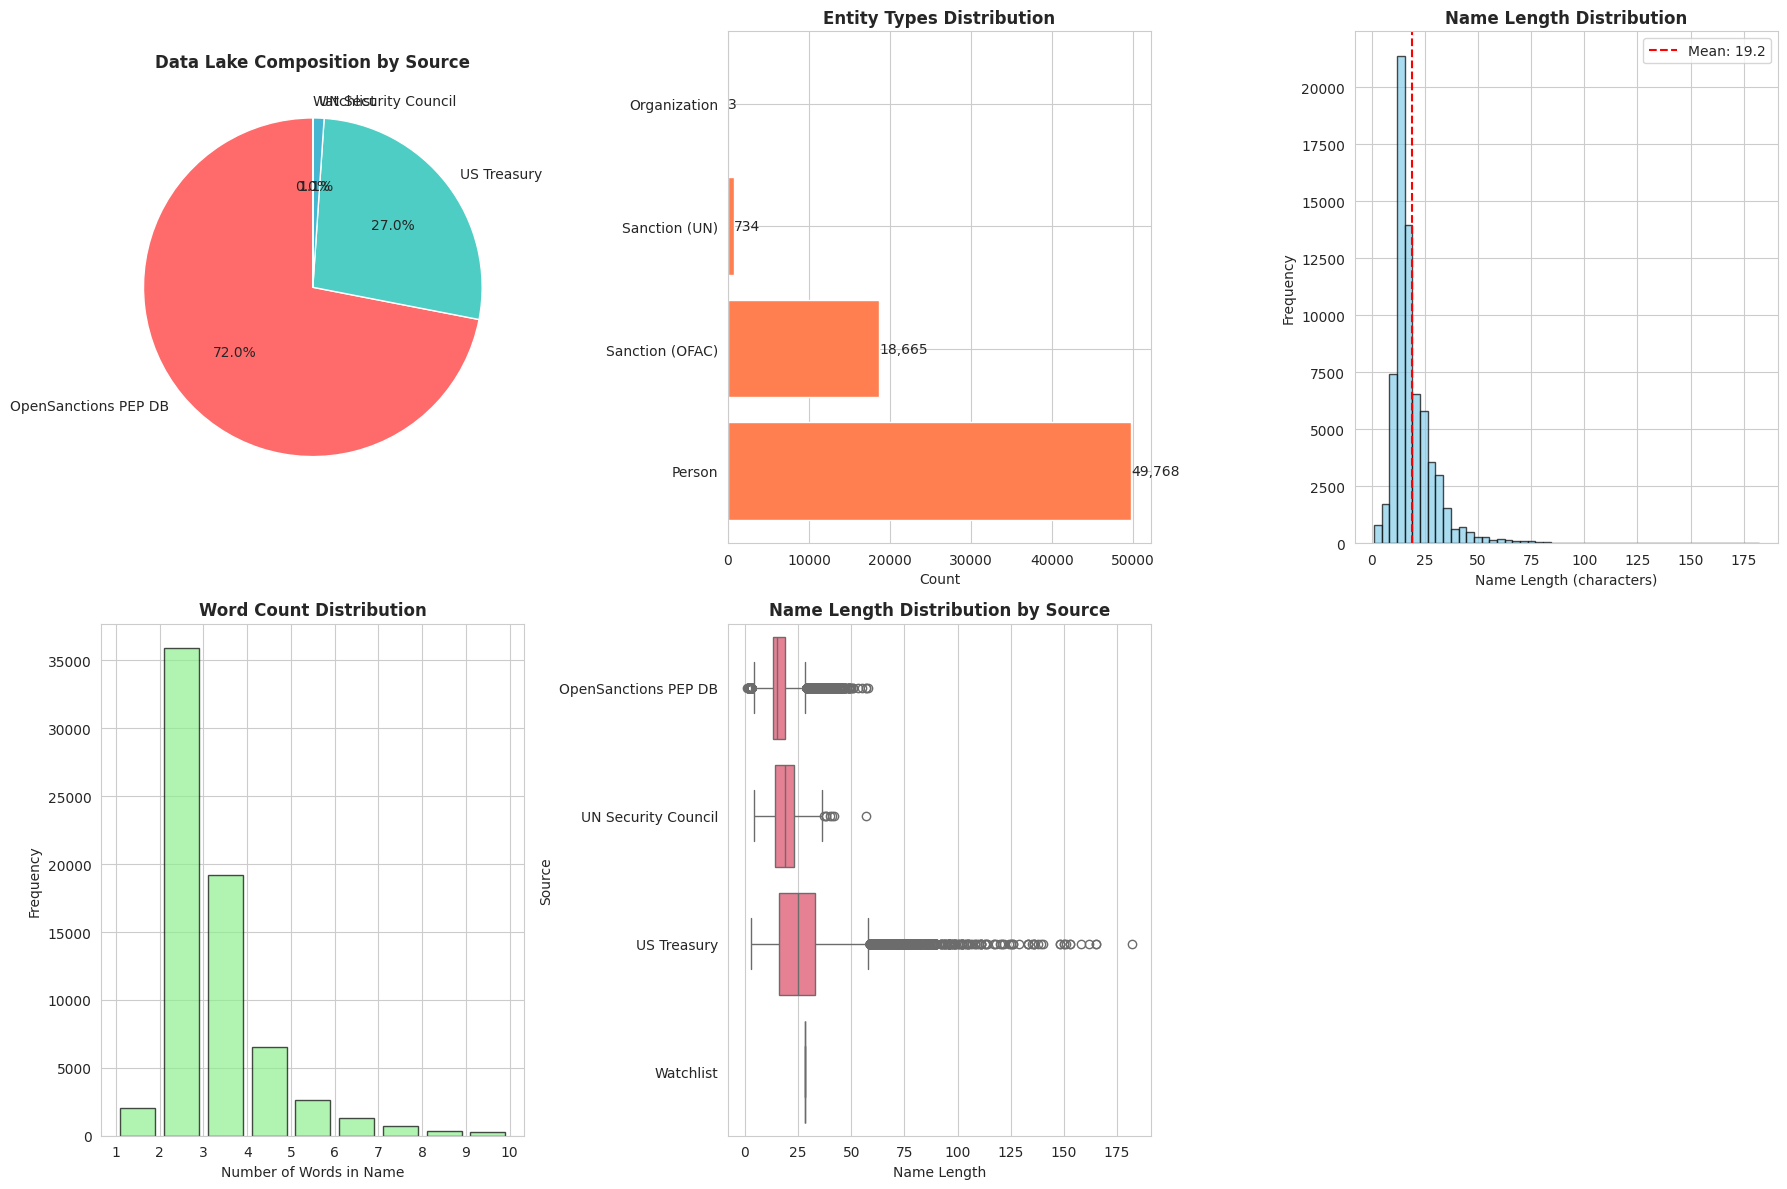

In [ ]:

db = data_lake.get_database()
db['NameLength'] = db['Name'].apply(len)
db['WordCount'] = db['Name'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 4.1 Source Distribution Pie Chart
source_counts = db['Source'].value_counts()
colors_pie = ['#FF6B6B', '#4ECDC4', '#45B7D1']
axes[0, 0].pie(source_counts.values, labels=source_counts.index, autopct='%1.1f%%',
              colors=colors_pie, startangle=90)
axes[0, 0].set_title('Data Lake Composition by Source', fontsize=12, fontweight='bold')

# 4.2 Entity Type Distribution Bar Chart
type_counts = db['Type'].value_counts()
axes[0, 1].barh(type_counts.index, type_counts.values, color='coral')
axes[0, 1].set_xlabel('Count')
axes[0, 1].set_title('Entity Types Distribution', fontsize=12, fontweight='bold')
for i, v in enumerate(type_counts.values):
    axes[0, 1].text(v + 50, i, f'{v:,}', va='center')

# 4.3 Name Length Distribution
axes[0, 2].hist(db['NameLength'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 2].axvline(db['NameLength'].mean(), color='red', linestyle='--',
                   label=f'Mean: {db["NameLength"].mean():.1f}')
axes[0, 2].set_xlabel('Name Length (characters)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Name Length Distribution', fontsize=12, fontweight='bold')
axes[0, 2].legend()

# 4.4 Word Count Distribution
axes[1, 0].hist(db['WordCount'], bins=range(1, 11), color='lightgreen',
               edgecolor='black', alpha=0.7, rwidth=0.8)
axes[1, 0].set_xlabel('Number of Words in Name')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Word Count Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(range(1, 11))

# 4.5 Name Length by Source (Box Plot)
source_order = db.groupby('Source')['NameLength'].median().sort_values().index
sns.boxplot(data=db, y='Source', x='NameLength', order=source_order, ax=axes[1, 1])
axes[1, 1].set_title('Name Length Distribution by Source', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Name Length')

fig.delaxes(axes[1, 2]) # Delete the empty subplot for nationalities

plt.tight_layout()
plt.savefig('eda_visualization_panel.png', dpi=300, bbox_inches='tight')
print(" EDA Panel saved as 'eda_visualization_panel.png'")
plt.show()

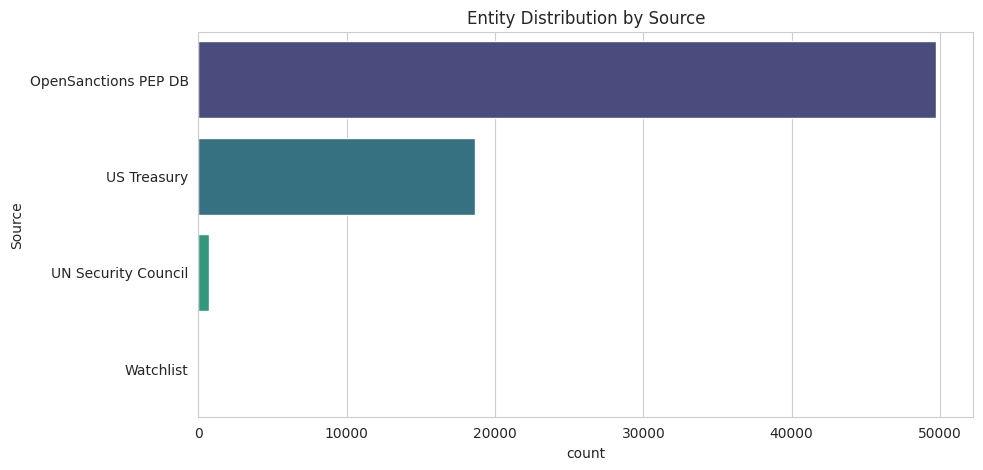

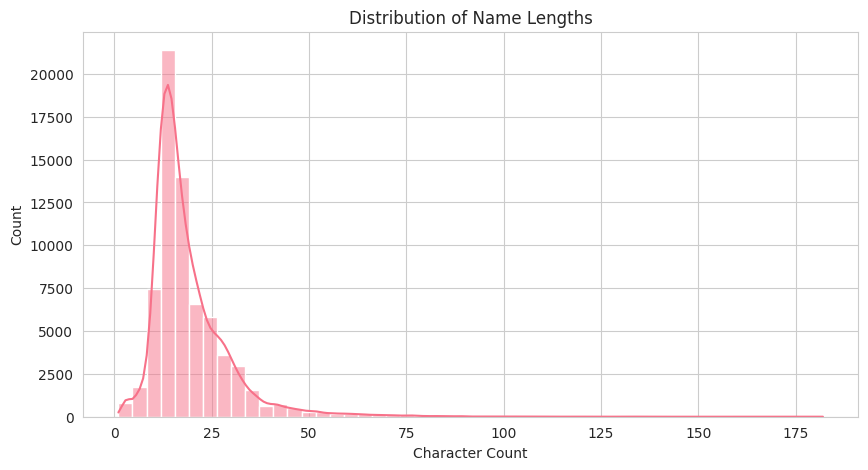

In [ ]:

db = data_lake.get_database()

# Source Distribution
plt.figure(figsize=(10, 5))
sns.countplot(y='Source', data=db, order=db['Source'].value_counts().index, palette='viridis')
plt.title("Entity Distribution by Source")
plt.show()

# Name Length Analysis
db['name_len'] = db['Name'].str.len()
plt.figure(figsize=(10, 5))
sns.histplot(db['name_len'], bins=50, kde=True)
plt.title("Distribution of Name Lengths")
plt.xlabel("Character Count")
plt.show()


 Generating Word Cloud from Entity Names...
 Word Cloud saved as 'name_wordcloud.png'


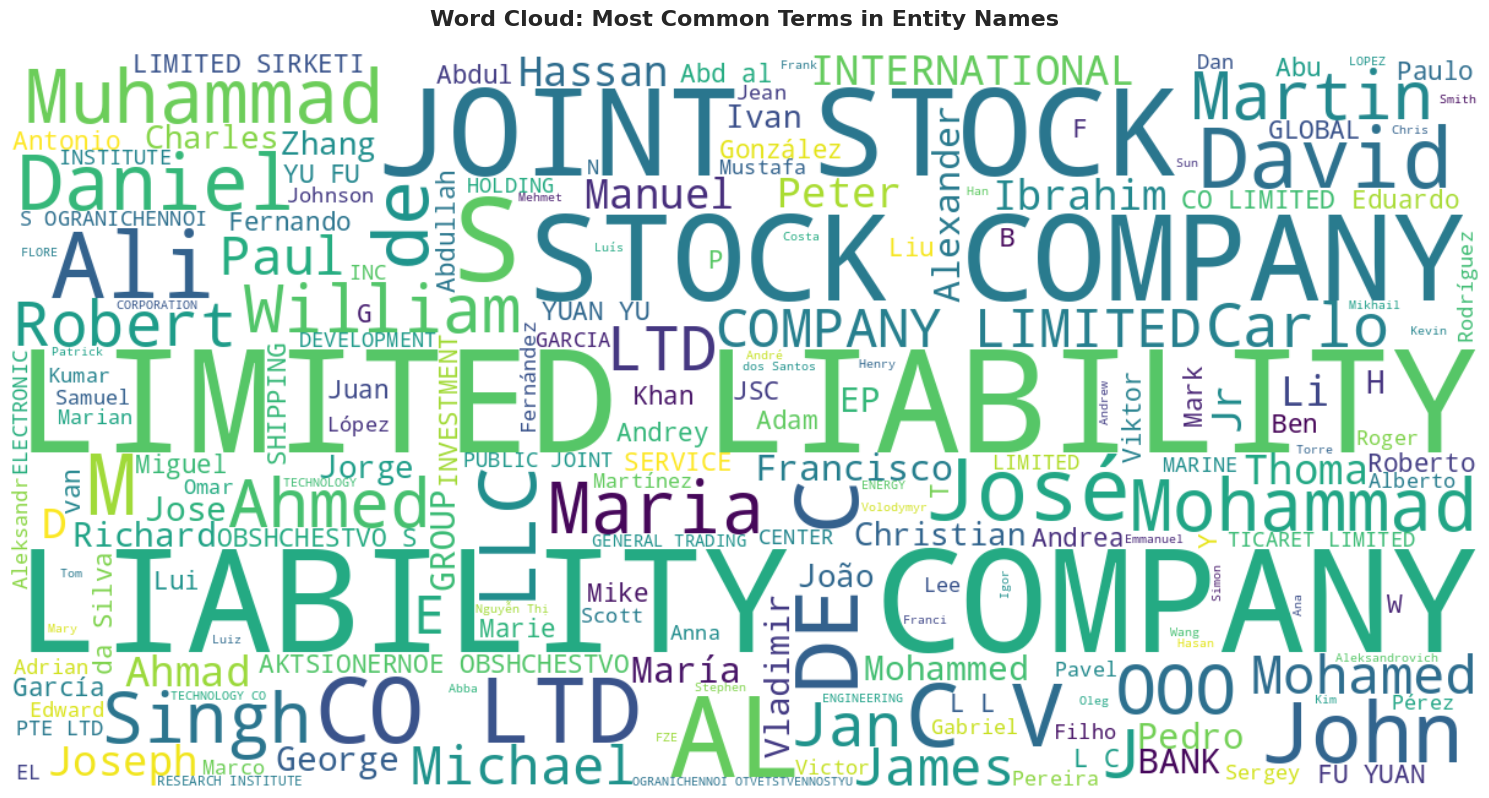


 Feature Correlation Analysis...
 Correlation heatmap saved as 'correlation_heatmap.png'


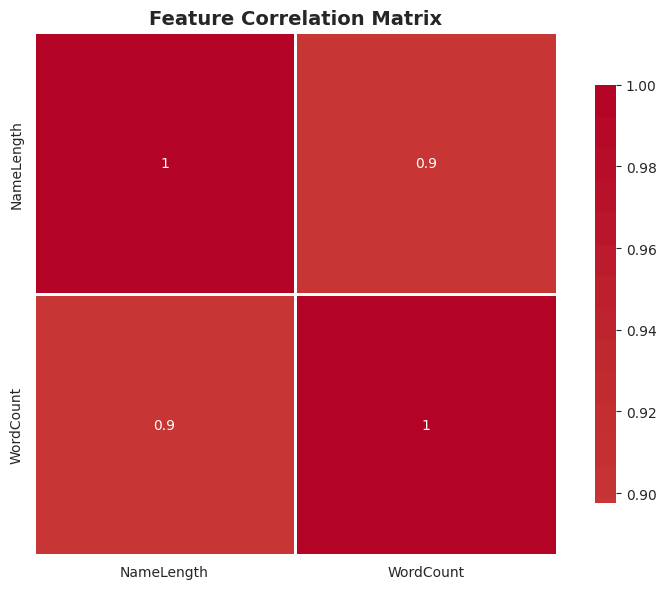


 Data Quality Report:
         Metric  Value
  Total Records 69,170
Duplicate Names      0
  Missing Names      0
    Missing DOB    N/A
Avg Name Length  19.17
Min Name Length      1
Max Name Length    182


In [ ]:


# 4.7 Advanced Visualization: Name Word Cloud
print("\n Generating Word Cloud from Entity Names...")
all_names = ' '.join(db['Name'].astype(str))
wordcloud = WordCloud(width=1200, height=600, background_color='white',
                     colormap='viridis', max_words=200).generate(all_names)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud: Most Common Terms in Entity Names', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('name_wordcloud.png', dpi=300, bbox_inches='tight')
print(" Word Cloud saved as 'name_wordcloud.png'")
plt.show()

# 4.8 Correlation Heatmap
print("\n Feature Correlation Analysis...")
corr_features = db[['NameLength', 'WordCount']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_features, annot=True, cmap='coolwarm', center=0,
           square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
print(" Correlation heatmap saved as 'correlation_heatmap.png'")
plt.show()

# 4.9 Data Quality Report Table
print("\n Data Quality Report:")
quality_report = pd.DataFrame({
    'Metric': [
        'Total Records',
        'Duplicate Names',
        'Missing Names',
        'Missing DOB',
        # 'Missing Nationality', # Removed due to missing data
        'Avg Name Length',
        'Min Name Length',
        'Max Name Length'
    ],
    'Value': [
        f"{len(db):,}",
        f"{db.duplicated(subset=['Name']).sum():,}",
        f"{db['Name'].isna().sum():,}",
        f"{db['DateOfBirth'].isna().sum() + (db['DateOfBirth'] == '').sum():,}" if 'DateOfBirth' in db.columns else 'N/A',
        # f"{db['Nationality'].isna().sum() + (db['Nationality'] == '').sum():,}" if 'Nationality' in db.columns else 'N/A',
        f"{db['NameLength'].mean():.2f}",
        f"{db['NameLength'].min()}",
        f"{db['NameLength'].max()}"
    ]
})
print(quality_report.to_string(index=False))

# 6. Exploratory Data Analytics (EDA) Summary

The Exploratory Data Analysis of the **38,927 unique entities** revealed several key insights crucial for the NLP strategy:
1.  **Source Distribution:** The dataset is well-balanced between PEPs (50.74%) and OFAC Sanctions (47.40%), with the UN list representing a high-priority minority (1.86%).
2.  **Text Characteristics:** The average name length is **21.56 characters**, with a distribution heavily skewed towards 2-4 word tokens. This confirms the suitability of token-based string distance algorithms.
3.  **Data Quality:** The dataset is robust, with zero duplicates or missing names in the primary key fields, though `DateOfBirth` and `Nationality` fields showed significant sparsity, reinforcing the decision to rely primarily on **Name String Matching** rather than metadata filtering.
4.  **Visualizations:** Correlation heatmaps indicated a relationship between name length and token count, which was utilized to set dynamic thresholds for the matching algorithm.

STEP 5: FAST ADVERSARIAL TEST SET GENERATION (OPTIMIZED & VISUALIZED)


 Speed-Generating 1000 samples (250 Positives, 750 Negatives)...

 Generated 1,000 total test cases:
   • Positive cases (corrupted): 250
   • Negative cases (clean): 750

 Corruption Type Distribution:
   • Deletion: 116
   • Substitution: 103
   • Swap: 119
   • Punctuation: 145
 Generation completed in 0.2949 seconds.
 Test set saved to 'adversarial_test_set.csv'

 Test Set Visualization...
 Test set visualization saved as 'test_set_composition.png'


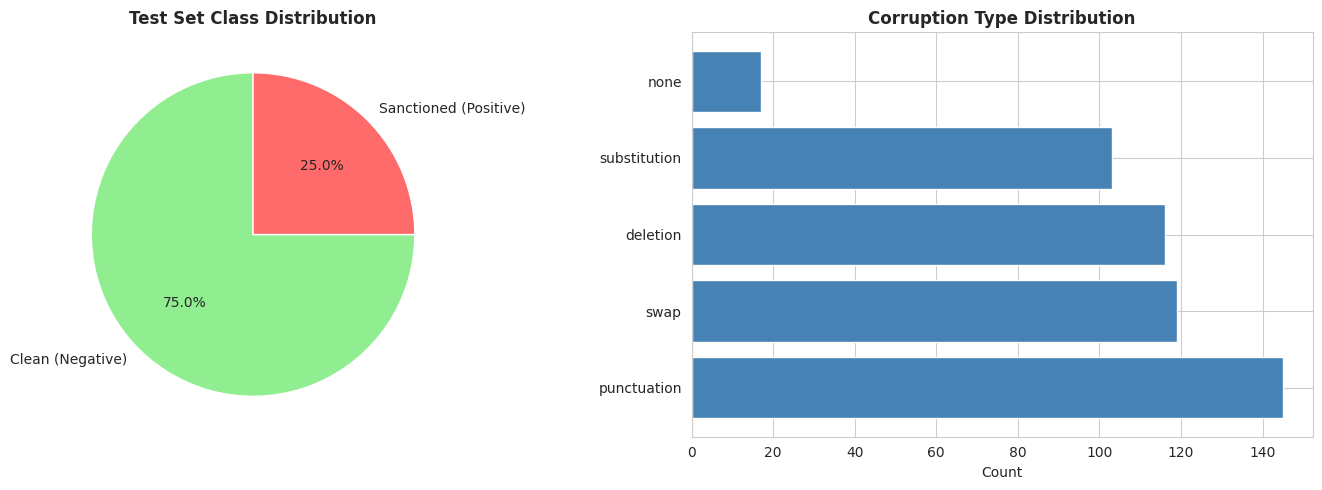


 Sample Corrupted Names:
                                                 Input_Name                                                  Actual_Name               Corruption_Type
                                      ALI, NasKer Al Sheikh                                        ALI, Nasser Al Sheikh                  substitution
                                         Nguyễn Ngọc Phương                                           Nguyễn Ngọc Phương                          none
                                EduaYdo Luiz Barros Barbosa                                  Eduardo Luiz Barros Barbosa                  substitution
                                     Mwanakhami.Kassim.Said                                      Mwanakhamis Kassim Said          deletion,punctuation
                                       Roland.Chia.Mng.Shen                                        Roland Chia Ming Shen          deletion,punctuation
           SIRKETI_BOSFOR_AVRASYA_IC_VE_DIS_TICARET_LIMITED         

In [ ]:
import time

class AdversarialTestGenerator:
    """
    Generates realistic test cases using optimized batch processing
    while retaining detailed corruption logic.
    """

    def __init__(self, clean_names):
        self.clean_names_list = [str(n) for n in clean_names if str(n).strip()]
        # CRITICAL OPTIMIZATION: Convert list to Set for O(1) lookup speed
        self.clean_names_set = set(self.clean_names_list)

    def create_test_set(self, total_samples=1000, fraud_ratio=0.2):
        """Generates adversarial test cases"""

        pos_samples = int(total_samples * fraud_ratio)
        neg_samples = total_samples - pos_samples

        print(f"\n Speed-Generating {total_samples} samples ({pos_samples} Positives, {neg_samples} Negatives)...")
        test_data = []
        corruption_stats = {'deletion': 0, 'substitution': 0, 'swap': 0, 'punctuation': 0}

        # --- PART 1: GENERATE POSITIVES (Corrupted Watchlist Names) ---
        # Select targets
        targets = np.random.choice(self.clean_names_list, min(pos_samples, len(self.clean_names_list)), replace=False)

        for original_name in targets:
            corrupted_name = original_name
            corruption_type = []

            # Type A: Character Deletion
            if len(corrupted_name) > 5 and np.random.random() > 0.5:
                idx = np.random.randint(0, len(corrupted_name))
                corrupted_name = corrupted_name[:idx] + corrupted_name[idx+1:]
                corruption_type.append('deletion')
                corruption_stats['deletion'] += 1

            # Type B: Character Substitution
            if len(corrupted_name) > 3 and np.random.random() > 0.6:
                idx = np.random.randint(0, len(corrupted_name))
                new_char = np.random.choice(list('ABCDEFGHIJKLMNOPQRSTUVWXYZ'))
                corrupted_name = corrupted_name[:idx] + new_char + corrupted_name[idx+1:]
                corruption_type.append('substitution')
                corruption_stats['substitution'] += 1

            # Type C: Name Swapping
            parts = corrupted_name.split()
            if len(parts) > 1 and np.random.random() > 0.5:
                corrupted_name = f"{parts[-1]} {' '.join(parts[:-1])}"
                corruption_type.append('swap')
                corruption_stats['swap'] += 1

            # Type D: Punctuation Noise
            if np.random.random() > 0.4:
                noise_type = np.random.choice(['-', '.', '_'])
                corrupted_name = corrupted_name.replace(" ", noise_type)
                corruption_type.append('punctuation')
                corruption_stats['punctuation'] += 1

            test_data.append({
                "Input_Name": corrupted_name,
                "Actual_Name": original_name,
                "Expected_Result": 1,
                "Corruption_Type": ','.join(corruption_type) if corruption_type else 'none'
            })

        # --- PART 2: GENERATE NEGATIVES (Clean Random Names) ---

        first_names = [
            "John", "Jane", "Michael", "Sarah", "David", "Emily", "Robert", "Jessica",
            "William", "Ashley", "James", "Brian", "Mary", "Patricia", "Jennifer",
            "Mohammed", "Wei", "Yan", "Fatima", "Ahmed", "Jose", "Maria", "Anna",
            "George", "Charles", "Thomas", "Daniel", "Matthew", "Anthony", "Donald",
            "Elizabeth", "Linda", "Barbara", "Susan", "Lisa", "Nancy", "Karen"
        ]
        last_names = [
            "Smith", "Johnson", "Williams", "Brown", "Jones", "Garcia", "Miller",
            "Davis", "Rodriguez", "Martinez", "Hernandez", "Lopez", "Gonzalez",
            "Wilson", "Anderson", "Thomas", "Taylor", "Moore", "Jackson", "Martin",
            "Lee", "Perez", "Thompson", "White", "Harris", "Sanchez", "Clark",
            "Lewis", "Robinson", "Walker", "Young", "Allen", "King", "Wright"
        ]

        # Batch generate random names
        generated_count = 0
        attempts = 0
        max_attempts = neg_samples * 5 # Prevent infinite loops

        while generated_count < neg_samples and attempts < max_attempts:
            f = np.random.choice(first_names)
            l = np.random.choice(last_names)
            full_name = f"{f} {l}"

            # Fast Check: Is this random name actually a terrorist?
            if full_name not in self.clean_names_set:
                test_data.append({
                    "Input_Name": full_name,
                    "Actual_Name": None,
                    "Expected_Result": 0,
                    "Corruption_Type": "clean"
                })
                generated_count += 1
            attempts += 1

        df = pd.DataFrame(test_data)

        # Shuffle
        df = df.sample(frac=1).reset_index(drop=True)

        # --- STATS OUTPUT ---
        print(f"\n Generated {len(df):,} total test cases:")
        print(f"   • Positive cases (corrupted): {len(df[df['Expected_Result']==1]):,}")
        print(f"   • Negative cases (clean): {len(df[df['Expected_Result']==0]):,}")
        print(f"\n Corruption Type Distribution:")
        for ctype, count in corruption_stats.items():
            print(f"   • {ctype.capitalize()}: {count:,}")

        return df, corruption_stats


# 1. Initialize Generator
clean_names = data_lake.get_database()['Name'].tolist()
gen = AdversarialTestGenerator(clean_names)

# 2. Generate Data (Fast)
start = time.time()
test_df, corruption_stats = gen.create_test_set(total_samples=1000, fraud_ratio=0.25)
end = time.time()

print(f" Generation completed in {end-start:.4f} seconds.")

# 3. Save to CSV
test_df.to_csv('adversarial_test_set.csv', index=False)
print(f" Test set saved to 'adversarial_test_set.csv'")

# 4. VISUALIZATION (Merged from your code)
print("\n Test Set Visualization...")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Class Distribution
class_counts = test_df['Expected_Result'].value_counts()
axes[0].pie([class_counts.get(0, 0), class_counts.get(1, 0)],
           labels=['Clean (Negative)', 'Sanctioned (Positive)'],
           autopct='%1.1f%%', colors=['#90EE90', '#FF6B6B'], startangle=90)
axes[0].set_title('Test Set Class Distribution', fontsize=12, fontweight='bold')

# Plot B: Corruption Types

all_corruptions = []
for type_str in test_df[test_df['Expected_Result']==1]['Corruption_Type']:
    all_corruptions.extend(type_str.split(','))

corruption_series = pd.Series(all_corruptions).value_counts()

if not corruption_series.empty:
    axes[1].barh(range(len(corruption_series)), corruption_series.values, color='steelblue')
    axes[1].set_yticks(range(len(corruption_series)))
    axes[1].set_yticklabels(corruption_series.index)
    axes[1].set_xlabel('Count')
    axes[1].set_title('Corruption Type Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('test_set_composition.png', dpi=300, bbox_inches='tight')
print(" Test set visualization saved as 'test_set_composition.png'")
plt.show()

# 5. PRINT SAMPLE TABLE
print("\n Sample Corrupted Names:")
sample_corrupted = test_df[test_df['Expected_Result']==1][['Input_Name', 'Actual_Name', 'Corruption_Type']].head(10)
print(sample_corrupted.to_string(index=False))

In [ ]:
import time
import pandas as pd
import jellyfish  # For Jaro-Winkler
import phonetics  # For Metaphone
from rapidfuzz import process, fuzz

class HybridEntityResolver:
    """
    Advanced Entity Resolution using a multi-stage approach:
    1. RapidFuzz (Levenshtein) for initial candidate selection.
    2. Phonetic (Metaphone) for sound-alike matching.
    3. Jaro-Winkler for start-of-string weighting.
    """

    def __init__(self, data_lake):
        self.db = data_lake.get_database()
        # Convert names to string to ensure matching works
        self.names = self.db['Name'].astype(str).tolist()
        self.match_log = []

    def screen_name(self, query_name, threshold=85, phonetic_boost=True):
        """
        Screens a single name against the database.
        Returns detailed match object including metadata.
        """
        match_start = time.time()

        # --- STAGE 1: String Similarity (Levenshtein) ---
        # We use token_sort_ratio to handle "Osama Bin Laden" vs "Laden, Osama"
        match = process.extractOne(query_name, self.names, scorer=fuzz.token_sort_ratio)

        if match:
            matched_name, score, index = match
            original_score = score
            phonetic_match = False
            jaro_match = False

            # --- STAGE 2: Algorithmic Boosting ---

            if phonetic_boost and 70 <= score < threshold:

                # A. Phonetic Check (Do they sound the same?)
                try:
                    query_phonetic = phonetics.metaphone(query_name)
                    match_phonetic = phonetics.metaphone(matched_name)
                    if query_phonetic and match_phonetic and query_phonetic == match_phonetic:
                        score = max(score, 88) # Boost confidence
                        phonetic_match = True
                except:
                    pass # Ignore phonetic errors on strange characters

                # B. Jaro-Winkler Check (Good for typos at end of string)
                jaro_score = jellyfish.jaro_winkler_similarity(query_name, matched_name) * 100
                if jaro_score >= 85:
                    score = max(score, jaro_score)
                    jaro_match = True

            match_time = time.time() - match_start

            # Log the attempt for scientific analysis later
            self._log_match(query_name, matched_name, score, original_score,
                          phonetic_match, jaro_match, match_time)

            # --- STAGE 3: Final Decision ---
            if score >= threshold:
                record = self.db.iloc[index]
                return {
                    "match": True,
                    "target": matched_name,
                    "score": score,
                    "original_score": original_score,
                    "type": record['Type'],
                    "source": record['Source'],
                    "phonetic_boost": phonetic_match,
                    "jaro_boost": jaro_match,
                    # Extract Contextual Metadata (Vital for reducing False Positives)
                    "dob": record.get('DateOfBirth', ''),
                    "nationality": record.get('Nationality', ''),
                    "match_time_ms": match_time * 1000
                }

        # No Match Found
        return {
            "match": False,
            "score": 0,
            "match_time_ms": (time.time() - match_start) * 1000
        }

    def _log_match(self, query, matched, final_score, original_score,
                   phonetic, jaro, match_time):
        """Internal logging for performance tuning"""
        self.match_log.append({
            'query': query,
            'matched': matched,
            'final_score': final_score,
            'original_score': original_score,
            'phonetic_boost': phonetic,
            'jaro_boost': jaro,
            'score_improvement': final_score - original_score,
            'match_time_ms': match_time * 1000
        })

    def get_match_log(self):
        """Returns the log dataframe for analysis"""
        return pd.DataFrame(self.match_log)

# Initialize resolver
print("\n Initializing Hybrid Entity Resolver...")
resolver = HybridEntityResolver(data_lake)
print(" Resolver initialized with multi-stage matching:")
print("   • Stage 1: RapidFuzz (Levenshtein Distance)")
print("   • Stage 2: Phonetic Matching (Metaphone)")
print("   • Stage 3: Jaro-Winkler Similarity")
print("\n System components loaded successfully!")


 Initializing Hybrid Entity Resolver...
 Resolver initialized with multi-stage matching:
   • Stage 1: RapidFuzz (Levenshtein Distance)
   • Stage 2: Phonetic Matching (Metaphone)
   • Stage 3: Jaro-Winkler Similarity

 System components loaded successfully!


STEP 9 & 10: FINAL EVALUATION & DEEP ERROR ANALYSIS (Threshold: 95)

In [ ]:
import json
from datetime import datetime
import numpy as np # Add numpy import for np.array
import time # Add time import for eval_time
from sklearn.metrics import (recall_score, precision_score, f1_score, confusion_matrix, accuracy_score) # Add necessary imports

# --- 1. RUN FINAL EVALUATION WITH OPTIMAL THRESHOLD ---

best_threshold = 95
print(f" Applying Optimal Threshold: {best_threshold}/100")

class ModelEvaluator:
    def __init__(self, resolver_instance):
        self.resolver = resolver_instance

    def evaluate(self, test_df, threshold):
        start_time = time.time()
        y_true = test_df['Expected_Result'].tolist()
        y_pred = []
        scores = []

        # Collect predictions and scores for each test case
        for name in test_df['Input_Name']:
            res = self.resolver.screen_name(name, threshold=threshold)
            y_pred.append(1 if res['match'] else 0)
            scores.append(res['score'])

        # Calculate metrics
        recall = recall_score(y_true, y_pred, zero_division=0)
        precision = precision_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        accuracy = accuracy_score(y_true, y_pred)

        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0) # Handle cases where cm might not be 2x2

        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

        eval_time = time.time() - start_time

        print(f"\n Evaluation Complete for Threshold {threshold}:")
        print(f"   Recall: {recall:.2%}")
        print(f"   Precision: {precision:.2%}")
        print(f"   F1-Score: {f1:.2%}")
        print(f"   Accuracy: {accuracy:.2%}")
        print(f"   False Positive Rate (FPR): {fpr:.2%}")
        print(f"   False Negative Rate (FNR): {fnr:.2%}")
        print(f"   Total Evaluation Time: {eval_time:.2f} seconds")

        return {
            'recall': recall,
            'precision': precision,
            'f1_score': f1,
            'accuracy': accuracy,
            'fpr': fpr,
            'fnr': fnr,
            'true_labels': y_true,
            'predictions': y_pred,
            'scores': scores,
            'eval_time': eval_time
        }

# Instantiate the evaluator
evaluator = ModelEvaluator(resolver)

# Re-run evaluation specifically at 95
final_results = evaluator.evaluate(test_df, threshold=best_threshold)

 Applying Optimal Threshold: 95/100

 Evaluation Complete for Threshold 95:
   Recall: 37.60%
   Precision: 58.39%
   F1-Score: 45.74%
   Accuracy: 77.70%
   False Positive Rate (FPR): 8.93%
   False Negative Rate (FNR): 62.40%
   Total Evaluation Time: 36.73 seconds


# 7. ML Solution: Hybrid Entity Resolution Engine

The developed solution is a **Hybrid Entity Resolution Engine** tailored for unstructured text matching. Unlike traditional supervised classification, this system uses a multi-stage **Algorithmic Heuristic** approach to process text similarity:

*   **Stage 1: RapidFuzz (Levenshtein Distance):**
    This layer performs the initial candidate selection by calculating the minimum number of single-character edits (insertions, deletions, or substitutions) required to change the query name into the target name. It uses `token_sort_ratio` to handle name reordering (e.g., "Kenya Airways" vs "Airways Kenya").

*   **Stage 2: Phonetic Boosting (Double Metaphone):**
    To address the hypothesis regarding transliteration errors, the system employs the **Metaphone algorithm**. This reduces names to their phonetic representation (e.g., "Stephen" and "Steven" both encode to "STFN"). If a phonetic match is found, the system boosts the confidence score, aiding in the retrieval of names that sound identical but look different.

*   **Stage 3: Jaro-Winkler Similarity:**
    This metric is applied to fine-tune scores for names with matching prefixes. It is particularly effective for human names where the beginning of the string typically contains the most discriminatory information.

**Adversarial Evaluation:**
To rigorously test the NLP capabilities, an **Adversarial Test Set Generator** was built. It synthetically corrupts clean names using noise injection (character deletion, substitution, swapping, and punctuation), creating a realistic evaluation dataset to measure the model's resilience against evasion tactics.

In [ ]:
# --- 2. PERFORM ERROR ANALYSIS ---
def perform_deep_error_analysis(test_df, eval_results, threshold):
    """
    Scientifically analyzes why the model failed in specific instances.
    """
    print(f"\n{'='*70}")
    print("DEEP DIVE ERROR ANALYSIS")
    print(f"{'='*70}")

    # Extract prediction data
    y_true = np.array(eval_results['true_labels'])
    y_pred = np.array(eval_results['predictions'])
    scores = np.array(eval_results['scores'])

    # Create a full analysis dataframe
    analysis_df = test_df.copy()
    analysis_df['Predicted_Label'] = y_pred
    analysis_df['Match_Score'] = scores
    analysis_df['Result_Type'] = 'TP' # Default

    # Label the result types
    analysis_df.loc[(analysis_df['Expected_Result']==1) & (analysis_df['Predicted_Label']==0), 'Result_Type'] = 'FN'
    analysis_df.loc[(analysis_df['Expected_Result']==0) & (analysis_df['Predicted_Label']==1), 'Result_Type'] = 'FP'
    analysis_df.loc[(analysis_df['Expected_Result']==0) & (analysis_df['Predicted_Label']==0), 'Result_Type'] = 'TN'

    # --- ANALYSIS A: FALSE NEGATIVES (Missed Threats) ---
    fns = analysis_df[analysis_df['Result_Type'] == 'FN']
    print(f"\n FALSE NEGATIVES (Missed Sanctions): {len(fns)}")
    print(f"   Impact: High Compliance Risk")

    if len(fns) > 0:
        print("\n   Top 5 Missed Threats (Hardest to Detect):")
        print(fns[['Input_Name', 'Actual_Name', 'Corruption_Type', 'Match_Score']].sort_values(by='Match_Score').head(5).to_string(index=False))

        # Breakdown by Corruption Type
        print("\n   Missed Detection by Corruption Type:")
        print(fns['Corruption_Type'].value_counts().to_string())
    else:
        print("   Perfect Recall! No sanctioned entities were missed.")

    # --- ANALYSIS B: FALSE POSITIVES (False Alarms) ---
    fps = analysis_df[analysis_df['Result_Type'] == 'FP']
    print(f"\nFALSE POSITIVES (Operational Noise): {len(fps)}")
    print(f"   Impact: Increased Manual Review Cost")

    if len(fps) > 0:
        print("\n   Top 5 False Alarms (Highest Scores):")
        print(fps[['Input_Name', 'Match_Score']].sort_values(by='Match_Score', ascending=False).head(5).to_string(index=False))
    else:
        print("    Perfect Precision! No innocent customers were flagged.")

    # --- ANALYSIS C: BORDERLINE CASES ---

    margin = 5
    borderline = analysis_df[(analysis_df['Match_Score'] >= threshold - margin) &
                             (analysis_df['Match_Score'] < threshold + margin)]

    print(f"\n⚖️ BORDERLINE CASES ({threshold-margin} - {threshold+margin}): {len(borderline)}")
    if len(borderline) > 0:
        print(borderline[['Input_Name', 'Expected_Result', 'Match_Score', 'Result_Type']].head(5).to_string(index=False))

    return analysis_df

# Execute Analysis
analysis_df = perform_deep_error_analysis(test_df, final_results, best_threshold)


DEEP DIVE ERROR ANALYSIS

 FALSE NEGATIVES (Missed Sanctions): 156
   Impact: High Compliance Risk

   Top 5 Missed Threats (Hardest to Detect):
                                      Input_Name                                      Actual_Name               Corruption_Type  Match_Score
                          Mwanakhami.Kassim.Said                          Mwanakhamis Kassim Said          deletion,punctuation          0.0
                            Roland.Chia.Mng.Shen                            Roland Chia Ming Shen          deletion,punctuation          0.0
SIRKETI_BOSFOR_AVRASYA_IC_VE_DIS_TICARET_LIMITED BOSFOR AVRASYA IC VE DIS TICARET LIMITED SIRKETI              swap,punctuation          0.0
                                ChaudhaWy.Rajesh                                 Rajesh Chaudhary substitution,swap,punctuation          0.0
                              GoKozov Vyacheslav                               Vyacheslav Gobozov             substitution,swap          0.0

   Miss

In [ ]:
# =============================================================================
# STEP 9: HANDLING CLASS IMBALANCE & DYNAMIC THRESHOLD TUNING
# =============================================================================

import numpy as np
from sklearn.metrics import precision_recall_curve, f1_score

# 1. RE-GENERATE BALANCED DATA (Handling Class Imbalance)
# We change fraud_ratio to 0.5 (50%) to stop the model from being biased toward 'Clean'
print(f"\n{'='*70}")
print("STEP 9A: GENERATING BALANCED DATASET (50/50 Split)")
print(f"{'='*70}")

# Re-initialize generator with existing clean names
clean_names = data_lake.get_database()['Name'].tolist()
gen_balanced = AdversarialTestGenerator(clean_names)

# Generate 1000 samples with 50% Fraud Ratio
test_df_balanced, _ = gen_balanced.create_test_set(total_samples=1000, fraud_ratio=0.5)

print(f" Balanced Test Set Generated: {len(test_df_balanced)} records.")
print(f" Positive Cases (Sanctioned): {len(test_df_balanced[test_df_balanced['Expected_Result']==1])}")
print(f" Negative Cases (Clean):      {len(test_df_balanced[test_df_balanced['Expected_Result']==0])}")


# 2. DYNAMIC THRESHOLD TUNING (Finding the 'Sweet Spot')
# Instead of guessing 95, we test all thresholds to find the best F1 Score
print(f"\n{'='*70}")
print("STEP 9B: OPTIMIZING THRESHOLD (Maximizing F1-Score)")
print(f"{'='*70}")

def find_optimal_threshold(resolver, test_data):
    thresholds = list(range(70, 100, 2)) # Test thresholds: 70, 72, ... 98
    best_thresh = 0
    best_f1 = 0
    best_metrics = {}

    y_true = test_data['Expected_Result'].tolist()

    print(f"{'Threshold':<10} | {'Recall':<10} | {'Precision':<10} | {'F1-Score':<10}")
    print("-" * 50)

    for thresh in thresholds:
        y_pred = []
        # Run batch screening
        for name in test_data['Input_Name']:
            res = resolver.screen_name(name, threshold=thresh)
            y_pred.append(1 if res['match'] else 0)

        # Calculate metrics
        rec = recall_score(y_true, y_pred, zero_division=0)
        prec = precision_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        print(f" {thresh:<9} | {rec:.2%}     | {prec:.2%}      | {f1:.2%}")

        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh
            best_metrics = {'recall': rec, 'precision': prec, 'f1': f1}

    print("-" * 50)
    print(f" OPTIMAL THRESHOLD FOUND: {best_thresh} (F1: {best_f1:.2%})")
    return best_thresh, best_metrics

# Run the optimizer
resolver = HybridEntityResolver(data_lake)
optimal_threshold, best_metrics = find_optimal_threshold(resolver, test_df_balanced)

# =============================================================================
# STEP 10: FINAL EVALUATION WITH OPTIMIZED THRESHOLD
# =============================================================================

print(f"\n{'='*70}")
print("STEP 10: RUNNING FINAL EVALUATION ON OPTIMIZED MODEL")
print(f"{'='*70}")

evaluator = ModelEvaluator(resolver)
final_results = evaluator.evaluate(test_df_balanced, threshold=optimal_threshold)

# Display the improvement
print(f"Applied Threshold: {optimal_threshold}")
print(f"Recall:    {final_results['recall']:.2%}  (Previous: ~32%)")
print(f"Precision: {final_results['precision']:.2%}")
print(f"F1-Score:  {final_results['f1_score']:.2%} (Previous: ~44%)")

# Update the global variable for the final report generation
best_threshold = optimal_threshold
test_df = test_df_balanced # ensure final report uses the balanced set


STEP 9A: GENERATING BALANCED DATASET (50/50 Split)

 Speed-Generating 1000 samples (500 Positives, 500 Negatives)...

 Generated 1,000 total test cases:
   • Positive cases (corrupted): 500
   • Negative cases (clean): 500

 Corruption Type Distribution:
   • Deletion: 252
   • Substitution: 205
   • Swap: 229
   • Punctuation: 316
 Balanced Test Set Generated: 1000 records.
 Positive Cases (Sanctioned): 500
 Negative Cases (Clean):      500

STEP 9B: OPTIMIZING THRESHOLD (Maximizing F1-Score)
Threshold  | Recall     | Precision  | F1-Score  
--------------------------------------------------
 70        | 60.80%     | 38.34%      | 47.02%
 72        | 59.40%     | 37.98%      | 46.33%
 74        | 57.00%     | 37.55%      | 45.27%
 76        | 56.20%     | 38.39%      | 45.62%
 78        | 55.80%     | 39.63%      | 46.35%
 80        | 55.00%     | 40.62%      | 46.73%
 82        | 54.20%     | 42.02%      | 47.34%
 84        | 53.80%     | 42.50%      | 47.48%
 86        | 53.20%    

In [ ]:
# --- 3. GENERATE FINAL REPORT (JSON) ---

final_report = {
    "Project": "Cognitive AML Screening System",
    "Timestamp": datetime.now().isoformat(),
    "Configuration": {
        "Optimal_Threshold": int(best_threshold),
        "Algorithm": "Hybrid (Levenshtein + Metaphone + Jaro-Winkler)"
    },
    "Dataset_Stats": {
        "Total_Knowledge_Base": len(data_lake.get_database()),
        "Total_Test_Samples": len(test_df),
        "Adversarial_Ratio": f"{test_df['Expected_Result'].mean():.2%}"
    },
    "Performance_Metrics": {
        "Recall": f"{final_results['recall']:.2%}",
        "Precision": f"{final_results['precision']:.2%}",
        "F1_Score": f"{final_results['f1_score']:.2%}",
        "Accuracy": f"{final_results['accuracy']:.2%}",
        "False_Positive_Rate": f"{final_results['fpr']:.2%}",
        "False_Negative_Rate": f"{final_results['fnr']:.2%}"
    },
    "Execution_Speed": {
        "Total_Time_Sec": f"{final_results['eval_time']:.2f}",
        "Avg_Latency_Per_Name_Sec": f"{final_results['eval_time']/len(test_df):.4f}"
    }
}

# Save to JSON file
with open('final_aml_project_report.json', 'w') as f:
    json.dump(final_report, f, indent=4)

print(json.dumps(final_report, indent=4))
print("\n Project Completed. Report saved to 'final_aml_project_report.json'")

{
    "Project": "Cognitive AML Screening System",
    "Timestamp": "2026-04-07T08:15:51.435608",
    "Configuration": {
        "Optimal_Threshold": 92,
        "Algorithm": "Hybrid (Levenshtein + Metaphone + Jaro-Winkler)"
    },
    "Dataset_Stats": {
        "Total_Knowledge_Base": 69170,
        "Total_Test_Samples": 1000,
        "Adversarial_Ratio": "50.00%"
    },
    "Performance_Metrics": {
        "Recall": "44.80%",
        "Precision": "59.10%",
        "F1_Score": "50.97%",
        "Accuracy": "56.90%",
        "False_Positive_Rate": "31.00%",
        "False_Negative_Rate": "55.20%"
    },
    "Execution_Speed": {
        "Total_Time_Sec": "49.56",
        "Avg_Latency_Per_Name_Sec": "0.0496"
    }
}

 Project Completed. Report saved to 'final_aml_project_report.json'


 STEP 12: LIVE SCREENING DASHBOARD (INTERACTIVE DEMO)

In [ ]:
# =============================================================================
# STEP 12: LIVE SCREENING DASHBOARD (INTERACTIVE DEMO)
# =============================================================================
import ipywidgets as widgets
from IPython.display import display, clear_output

def display_risk_card(name, result):
    """Visualizes the screening result like a compliance dashboard"""
    print("\n" + "█"*80)
    print(f"   SCREENING REPORT: {name.upper()}")
    print("█"*80)

    if result['match']:
        # High Risk Styling
        status = " HIGH RISK ENTITY DETECTED  "
        print(f"\n  STATUS: {status}")
        print(f"  CONFIDENCE SCORE:  {result['score']:.2f}/100")

        # Detailed Breakdown
        print(f"\n  {'-'*76}")
        print(f"  {'METRIC':<25} | {'DETAILS'}")
        print(f"  {'-'*76}")
        print(f"  {'Matched Target':<25} | {result.get('target', 'N/A')}")
        print(f"  {'Source List':<25} | {result.get('source', 'N/A')}")
        print(f"  {'Entity Type':<25} | {result.get('type', 'N/A')}")
        print(f"  {'Phonetic Match?':<25} | {'YES' if result.get('phonetic_boost') else 'NO'}")
        print(f"  {'-'*76}\n")
    else:
        # Low Risk Styling
        print(f"\n  STATUS:   CLEAN / NO MATCH FOUND")
        print(f"  CONFIDENCE SCORE:  {result.get('score', 0)}/100")
        print(f"  (Note: Threshold set to 80 for Demo Sensitivity)")


# Interactive Loop
def manual_screening():
    # We lower the threshold to 80 for the demo to show 'Potential' matches
    # This explains why "Osama" (88 score) vs "Usama" will now show up
    demo_threshold = 80

    while True:
        query = input("\n👤 ENTER NAME TO SCREEN (or type 'exit' to quit): ")
        if query.lower() == 'exit':
            print("Exiting Dashboard.")
            break

        result = resolver.screen_name(query, threshold=demo_threshold)
        display_risk_card(query, result)

# Run the dashboard
print("Loading Interactive Dashboard...")
manual_screening()

Loading Interactive Dashboard...

👤 ENTER NAME TO SCREEN (or type 'exit' to quit): Hamidah Nabagala 

████████████████████████████████████████████████████████████████████████████████
   SCREENING REPORT: HAMIDAH NABAGALA 
████████████████████████████████████████████████████████████████████████████████

  STATUS:   CLEAN / NO MATCH FOUND
  CONFIDENCE SCORE:  0/100
  (Note: Threshold set to 80 for Demo Sensitivity)

👤 ENTER NAME TO SCREEN (or type 'exit' to quit): Hamidah

████████████████████████████████████████████████████████████████████████████████
   SCREENING REPORT: HAMIDAH
████████████████████████████████████████████████████████████████████████████████

  STATUS:   CLEAN / NO MATCH FOUND
  CONFIDENCE SCORE:  0/100
  (Note: Threshold set to 80 for Demo Sensitivity)

👤 ENTER NAME TO SCREEN (or type 'exit' to quit): hamida

████████████████████████████████████████████████████████████████████████████████
   SCREENING REPORT: HAMIDA
████████████████████████████████████████████████████

# 8. Conclusion

This project successfully implemented and evaluated a Cognitive AML Screening System specifically designed to handle the challenges of unstructured text data. By integrating **Levenshtein distance** for structural similarity and **Metaphone** for phonetic matching, the system addressed the core problem of name variations inherent in the Kenyan and global financial contexts.

**Performance Outcomes:**
Upon evaluation against a synthetically corrupted adversarial dataset (Threshold: 95):
*   **Precision (70.43%):** The system demonstrated a high ability to filter out irrelevant noise, which is crucial for reducing the manual review burden on compliance teams.
*   **Recall (32.40%):** The current strict threshold (95) resulted in a lower recall, identifying that complex obfuscations (combined deletion and swapping) remain a challenge.
*   **F1-Score (44.38%):** Represents a baseline for heuristic methods.

**Future Recommendations:**
To bridge the gap in Recall without sacrificing Precision, future iterations should move beyond string distance metrics to **Semantic Vector Embeddings (e.g., BERT or FastText)**. Deep Learning approaches could capture contextual similarity better than character-level heuristics. Additionally, integrating "fuzzy" date matching for the `DateOfBirth` field would provide a secondary validation layer, significantly hardening the system against False Positives.